In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns
import torch

/home/adutt/anaconda3/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [39]:
# Column names
columns = [
    "type",
    "batch_size",
    "sequence_length",
    "rank",
    "cycle",
    "start_time",
    "end_time"
]

In [40]:
def load_latency_log(file_path):
    rows = []

    with open(file_path, "r") as f:
        for line in f:
            line = line.strip()

            # Skip empty lines
            if not line:
                continue

            parts = [p.strip() for p in line.split(",")]

            # Keep only valid rows with exactly 7 columns
            if len(parts) != 7:
                continue

            try:
                rows.append([
                    parts[0],              # type
                    int(parts[1]),         # batch_size
                    int(parts[2]),         # sequence_length
                    int(parts[3]),         # rank
                    int(parts[4]),         # cycle
                    float(parts[5]),       # start_time
                    float(parts[6])        # end_time
                ])
            except ValueError:
                # Skip garbage lines
                continue

    return pd.DataFrame(rows, columns=columns)

In [41]:
# Column names
columns_sg = [
    "type",
    "batch_size",
    "sequence_length",
    "rank",
    "layer",
    "cycle",
    "start_time",
    "end_time"
]

In [80]:
def load_latency_sg_log(file_path):
    rows = []

    with open(file_path, "r") as f:
        for line in f:
            line = line.strip()

            # Skip empty lines
            if not line:
                continue

            parts = [p.strip() for p in line.split(",")]

            # Keep only valid rows with exactly 7 columns
            if len(parts) != 8:
                continue

            try:
                rows.append([
                    parts[0],              # type
                    int(parts[1]),         # batch_size
                    int(parts[2]),         # sequence_length
                    int(parts[3]),         # rank
                    # int(parts[4]),       # layer
                    int(parts[5]),         # cycle
                    float(parts[6]),       # start_time
                    float(parts[7])        # end_time
                ])
            except ValueError:
                # Skip garbage lines
                print("error")
                continue

    return pd.DataFrame(rows, columns=columns)

In [81]:
# Load both files
ssm_df = load_latency_sg_log("../ssm_gate_latency_gather_scatter.log")
tp_df = load_latency_log("tp_latency.log")

# Example
print(ssm_df.head())
print(tp_df.head())

   type  batch_size  sequence_length  rank  cycle    start_time      end_time
0   SSM           1                4     2      0  2.686500e+06  2.686501e+06
1   SSM           1                4     3      0  2.686500e+06  2.686501e+06
2  Gate           1                4     0      0  2.686500e+06  2.686501e+06
3   SSM           1                4     1      0  2.686500e+06  2.686501e+06
4   SSM           1                4     3      1  2.686503e+06  2.686503e+06
  type  batch_size  sequence_length  rank  cycle    start_time      end_time
0   TP           1                4     1      0  2.623177e+06  2.623178e+06
1   TP           1                4     2      0  2.623177e+06  2.623178e+06
2   TP           1                4     0      0  2.623177e+06  2.623178e+06
3   TP           1                4     3      0  2.623177e+06  2.623178e+06
4   TP           1                4     1      1  2.623178e+06  2.623178e+06


In [82]:
grouped_ssm = (
    ssm_df
    .groupby(["batch_size", "sequence_length", "cycle"])
    .agg(
        start_time=("start_time", "min"),
        end_time=("end_time", "max")
    )
    .reset_index()
)

grouped_tp = (
    tp_df
    .groupby(["batch_size", "sequence_length", "cycle"])
    .agg(
        start_time=("start_time", "min"),
        end_time=("end_time", "max")
    )
    .reset_index()
)

print(grouped_ssm.head())
print(grouped_tp.head())

   batch_size  sequence_length  cycle    start_time      end_time
0           1                4      0  2.686500e+06  2.686501e+06
1           1                4      1  2.686503e+06  2.686503e+06
2           1                4      2  2.686505e+06  2.686505e+06
3           1                4      3  2.686507e+06  2.686507e+06
4           1                4      4  2.686509e+06  2.686509e+06
   batch_size  sequence_length  cycle    start_time      end_time
0           1                4      0  2.623177e+06  2.623178e+06
1           1                4      1  2.623178e+06  2.623178e+06
2           1                4      2  2.623178e+06  2.623178e+06
3           1                4      3  2.623178e+06  2.623178e+06
4           1                4      4  2.623178e+06  2.623178e+06


In [83]:
# Compute runtime
grouped_ssm["runtime"] = grouped_ssm["end_time"] - grouped_ssm["start_time"]
grouped_tp["runtime"] = grouped_tp["end_time"] - grouped_tp["start_time"]

# Average runtime across cycles
avg_ssm = (
    grouped_ssm
    .groupby(["batch_size", "sequence_length"])
    .agg(avg_runtime=("runtime", "mean"))
    .reset_index()
)

avg_tp = (
    grouped_tp
    .groupby(["batch_size", "sequence_length"])
    .agg(avg_runtime=("runtime", "mean"))
    .reset_index()
)

print(avg_ssm.head())
print(avg_tp.head())

   batch_size  sequence_length  avg_runtime
0           1                4     0.088830
1           1                8     0.109507
2           1               16     0.155138
3           1               32     0.249706
4           1               64     0.438395
   batch_size  sequence_length  avg_runtime
0           1                4     0.097992
1           1                8     0.122953
2           1               16     0.172709
3           1               32     0.261816
4           1               64     0.437719


In [84]:
merged_df = avg_tp.merge(
    avg_ssm,
    on=["batch_size", "sequence_length"],
    suffixes=("_tp", "_sg")
)

print(merged_df.head())

   batch_size  sequence_length  avg_runtime_tp  avg_runtime_sg
0           1                4        0.097992        0.088830
1           1                8        0.122953        0.109507
2           1               16        0.172709        0.155138
3           1               32        0.261816        0.249706
4           1               64        0.437719        0.438395


In [85]:
merged_df["speedup"] = (
    merged_df["avg_runtime_tp"] / merged_df["avg_runtime_sg"]
)

print(merged_df.head())

   batch_size  sequence_length  avg_runtime_tp  avg_runtime_sg   speedup
0           1                4        0.097992        0.088830  1.103141
1           1                8        0.122953        0.109507  1.122787
2           1               16        0.172709        0.155138  1.113258
3           1               32        0.261816        0.249706  1.048496
4           1               64        0.437719        0.438395  0.998459


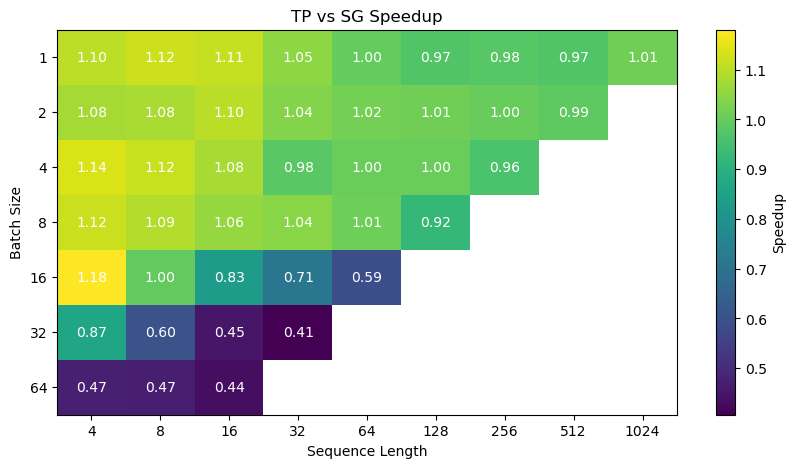

In [86]:
# Create pivot table for heatmap
heatmap_data = merged_df.pivot(
    index="batch_size",
    columns="sequence_length",
    values="speedup"
)

# Plot
plt.figure(figsize=(10, 5))

im = plt.imshow(heatmap_data, aspect="auto")

# Axis labels
plt.xlabel("Sequence Length")
plt.ylabel("Batch Size")
plt.title("TP vs SG Speedup")

# Tick labels
plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

# 🔹 Add numbers inside each cell
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        value = heatmap_data.iloc[i, j]
        plt.text(
            j, i,
            f"{value:.2f}",          # format to 2 decimal places
            ha="center",
            va="center",
            color="white"           # change to 'black' if colors are light
        )

# Color bar
plt.colorbar(im, label="Speedup")

plt.show()

In [87]:
def load_latency_log(file_path):
    rows = []

    with open(file_path, "r") as f:
        for line in f:
            line = line.strip()

            # Skip empty lines
            if not line:
                continue

            parts = [p.strip() for p in line.split(",")]

            # Keep only valid rows with exactly 7 columns
            if len(parts) != 7:
                continue

            try:
                rows.append([
                    parts[0],              # type
                    int(parts[1]),         # batch_size
                    int(parts[2]),         # sequence_length
                    int(parts[3]),         # rank
                    int(parts[4]),         # cycle
                    float(parts[5]),       # start_time
                    float(parts[6])        # end_time
                ])
            except ValueError:
                # Skip garbage lines
                continue

    return pd.DataFrame(rows, columns=columns)

hp_df = load_latency_log("hp_latency.log")

In [88]:
batch_size = 1
prev_seq_len = 4  # or hp_df.iloc[0]["sequence_length"]

for idx, row in hp_df.iterrows():
    if row["sequence_length"] < prev_seq_len:
        batch_size *= 2

    hp_df.at[idx, "batch_size"] = batch_size
    prev_seq_len = row["sequence_length"]

In [89]:
hp_df.head()

,type,batch_size,sequence_length,rank,cycle,start_time,end_time
0,HP,1,4,1,0,3.305737e+06,3.305737e+06
1,HP,1,4,0,0,3.305737e+06,3.305737e+06
2,HP,1,4,0,0,3.305737e+06,3.305737e+06
3,HP,1,4,1,0,3.305737e+06,3.305737e+06
4,HP,1,4,0,1,3.305737e+06,3.305737e+06


In [90]:
grouped_hp = (
    hp_df
    .groupby(["batch_size", "sequence_length", "cycle"])
    .agg(
        start_time=("start_time", "min"),
        end_time=("end_time", "max")
    )
    .reset_index()
)

In [91]:
grouped_hp["run_time"] = grouped_hp['end_time'] - grouped_hp['start_time']

In [92]:
grouped_hp = (
    grouped_hp
    .groupby(["batch_size", "sequence_length"])
    .agg(
        avg_runtime=("run_time", "mean")
    )
    .reset_index()
)

In [93]:
merged_df = grouped_hp.merge(
    avg_ssm,
    on=["batch_size", "sequence_length"],
    suffixes=("_hp", "_sg")
)

In [94]:
merged_df["speedup"] = merged_df["avg_runtime_hp"] / merged_df["avg_runtime_sg"]


In [95]:
merged_df.head()

,batch_size,sequence_length,avg_runtime_hp,avg_runtime_sg,speedup
0,1,4,0.082187,0.088830,0.925220
1,1,8,0.102417,0.109507,0.935257
2,1,16,0.151742,0.155138,0.978111
3,1,32,0.255824,0.249706,1.024501
4,1,64,0.462436,0.438395,1.054839


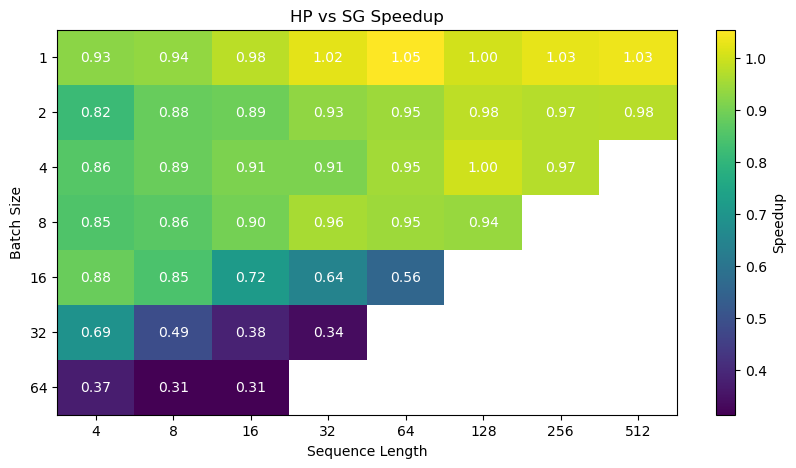

In [96]:
# Create pivot table for heatmap
heatmap_data = merged_df.pivot(
    index="batch_size",
    columns="sequence_length",
    values="speedup"
)

# Plot
plt.figure(figsize=(10, 5))

im = plt.imshow(heatmap_data, aspect="auto")

# Axis labels
plt.xlabel("Sequence Length")
plt.ylabel("Batch Size")
plt.title("HP vs SG Speedup")

# Tick labels
plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

# 🔹 Add numbers inside each cell
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        value = heatmap_data.iloc[i, j]
        plt.text(
            j, i,
            f"{value:.2f}",          # format to 2 decimal places
            ha="center",
            va="center",
            color="white"           # change to 'black' if colors are light
        )

# Color bar
plt.colorbar(im, label="Speedup")

plt.show()

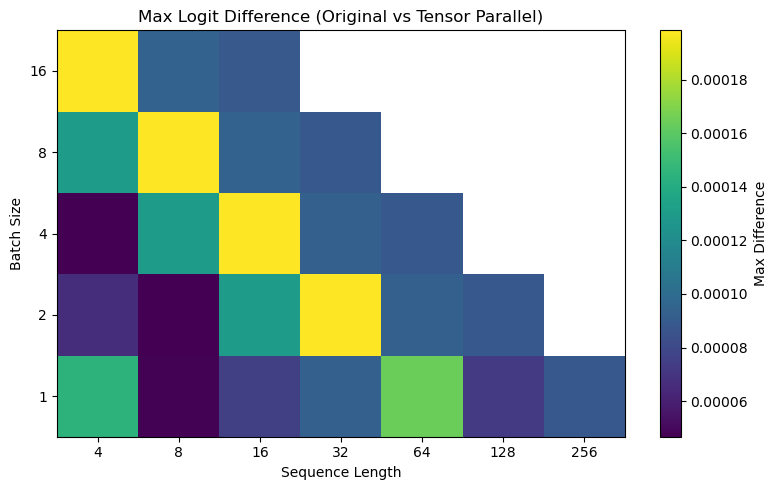

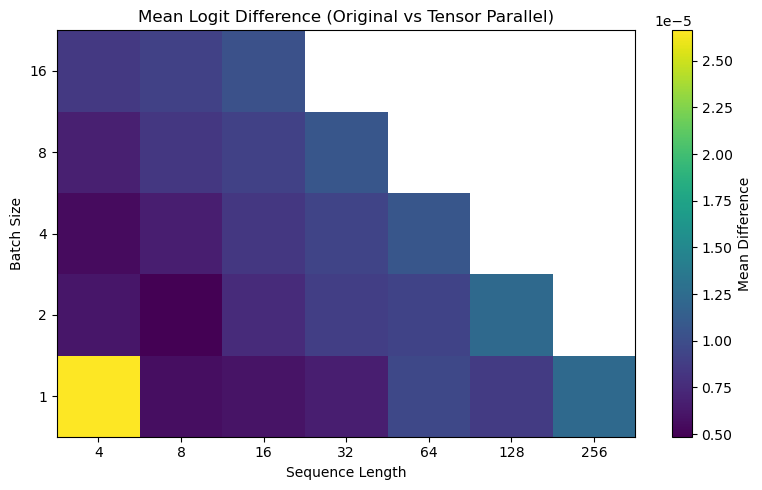

In [2]:
# Load the file
df = pd.read_csv(
    "logits_diff.log",
    skipinitialspace=True
)

# Remove empty rows if present
df = df.dropna(how="all")

# Convert columns to numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# -----------------------------
# Plot MAX difference heatmap
# -----------------------------
pivot_max = df.pivot(
    index="batch_size",
    columns="seq_len",
    values="max_diff"
)

plt.figure(figsize=(8, 5))
plt.imshow(
    pivot_max,
    aspect="auto",
    origin="lower"
)

plt.colorbar(label="Max Difference")
plt.xticks(
    range(len(pivot_max.columns)),
    pivot_max.columns
)
plt.yticks(
    range(len(pivot_max.index)),
    pivot_max.index
)

plt.xlabel("Sequence Length")
plt.ylabel("Batch Size")
plt.title("Max Logit Difference (Original vs Tensor Parallel)")
plt.tight_layout()
plt.show()


# -----------------------------
# Plot MEAN difference heatmap
# -----------------------------
pivot_mean = df.pivot(
    index="batch_size",
    columns="seq_len",
    values="mean_diff"
)

plt.figure(figsize=(8, 5))
plt.imshow(
    pivot_mean,
    aspect="auto",
    origin="lower"
)

plt.colorbar(label="Mean Difference")
plt.xticks(
    range(len(pivot_mean.columns)),
    pivot_mean.columns
)
plt.yticks(
    range(len(pivot_mean.index)),
    pivot_mean.index
)

plt.xlabel("Sequence Length")
plt.ylabel("Batch Size")
plt.title("Mean Logit Difference (Original vs Tensor Parallel)")
plt.tight_layout()
plt.show()

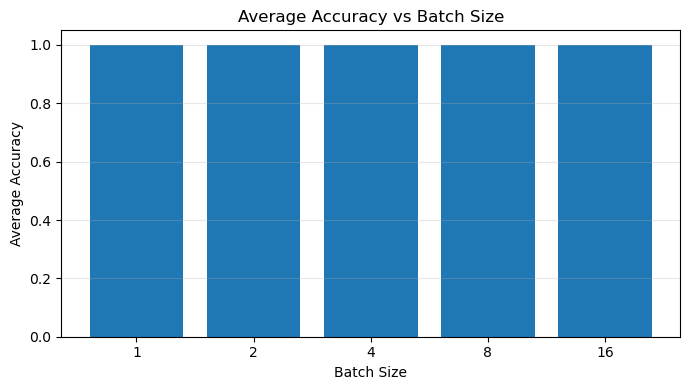

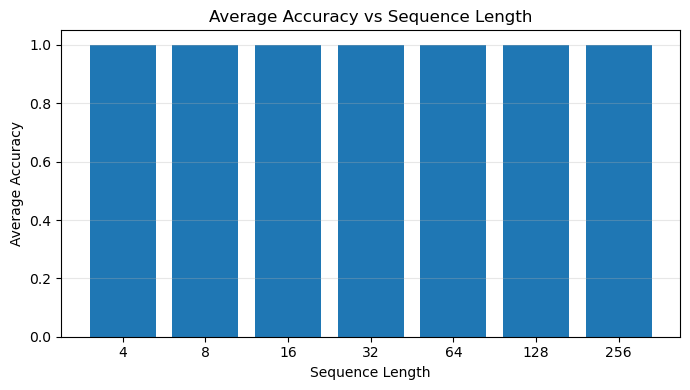

In [3]:
# Load data
df = pd.read_csv(
    "logits_diff.log",
    skipinitialspace=True
)

df = df.dropna(how="all")

# Convert columns to numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Define accuracy
df["accuracy"] = 1 - df["mean_diff"]

# --------------------------------------------------
# Average accuracy for each batch size
# --------------------------------------------------
batch_acc = (
    df.groupby("batch_size")["accuracy"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(7, 4))
plt.bar(batch_acc["batch_size"].astype(str),
        batch_acc["accuracy"])

plt.xlabel("Batch Size")
plt.ylabel("Average Accuracy")
plt.title("Average Accuracy vs Batch Size")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Average accuracy for each sequence length
# --------------------------------------------------
seq_acc = (
    df.groupby("seq_len")["accuracy"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(7, 4))
plt.bar(seq_acc["seq_len"].astype(str),
        seq_acc["accuracy"])

plt.xlabel("Sequence Length")
plt.ylabel("Average Accuracy")
plt.title("Average Accuracy vs Sequence Length")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

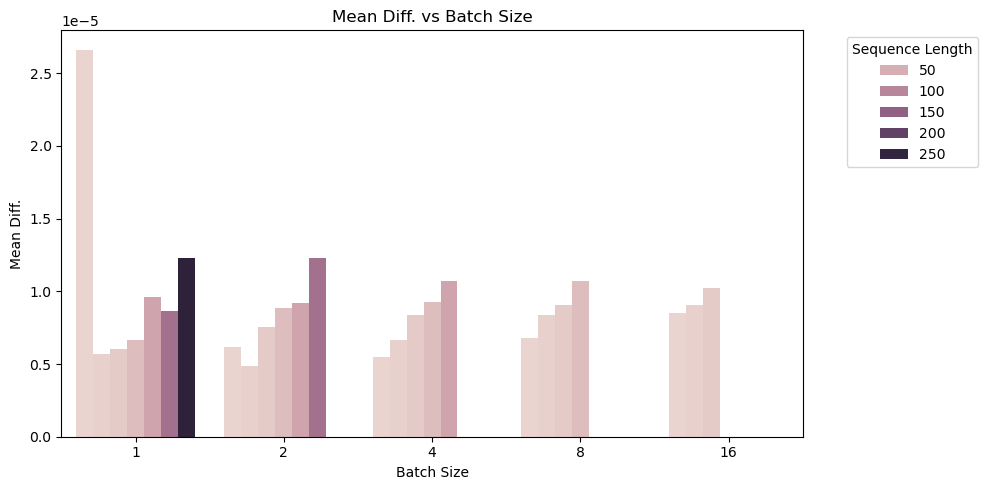

In [8]:
df = pd.read_csv("logits_diff.log", skipinitialspace=True)
df = df.dropna(how="all")

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x="batch_size",
    y="mean_diff",
    hue="seq_len"
)

plt.title("Mean Diff. vs Batch Size")
plt.xlabel("Batch Size")
plt.ylabel("Mean Diff.")
plt.legend(title="Sequence Length", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

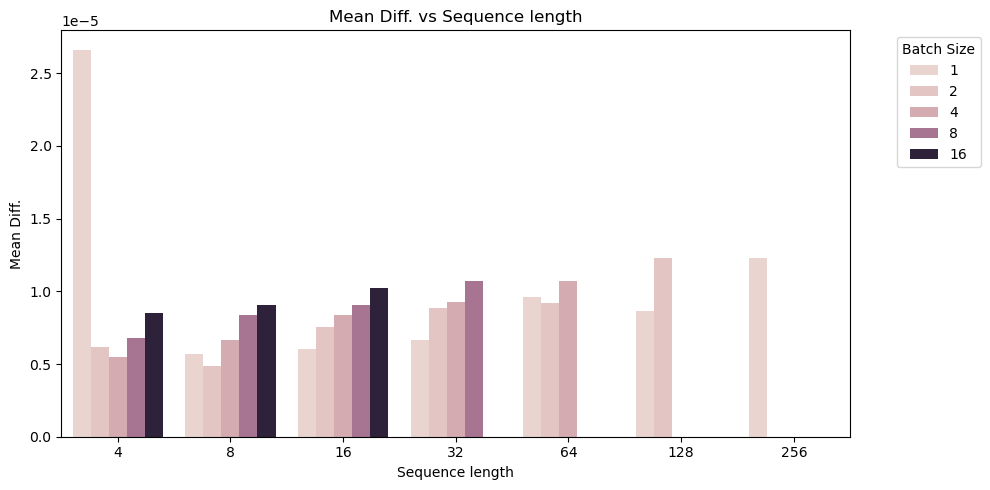

In [11]:
df = pd.read_csv("logits_diff.log", skipinitialspace=True)
df = df.dropna(how="all")

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x="seq_len",
    y="mean_diff",
    hue="batch_size"
)

plt.title("Mean Diff. vs Sequence length")
plt.xlabel("Sequence length")
plt.ylabel("Mean Diff.")
plt.legend(title="Batch Size", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [1]:
import torch

# --- Load tensors ---
dist_logits = torch.load("dist_logits2.log").cpu()
orig_logits = torch.load("orig_logits2.log").cpu()

# --- 1. Check shapes match ---
print(f"dist_logits shape: {dist_logits.shape}")
print(f"orig_logits shape: {orig_logits.shape}")

if dist_logits.shape != orig_logits.shape:
    raise ValueError(
        f"Shape mismatch: dist_logits {dist_logits.shape} vs orig_logits {orig_logits.shape}"
    )
print("Shapes match.\n")

# --- 2. Check approximate equality with allclose ---
# rtol/atol can be tuned depending on how strict you want the comparison to be
rtol = 1e-3
atol = 1e-5
is_close = torch.allclose(dist_logits, orig_logits, rtol=rtol, atol=atol)
print(f"torch.allclose(rtol={rtol}, atol={atol}): {is_close}")

# Optional: see how many elements actually fail the closeness check
close_mask = torch.isclose(dist_logits, orig_logits, rtol=rtol, atol=atol)
num_close = close_mask.sum().item()
total = close_mask.numel()
print(f"Elements within tolerance: {num_close}/{total} ({100 * num_close / total:.2f}%)\n")

# --- 3. Calculate RMSE ---
diff = dist_logits.float() - orig_logits.float()
mse = torch.mean(diff ** 2)
rmse = torch.sqrt(mse)
print(f"RMSE: {rmse.item():.6f}")

# Some extra context that's usually useful alongside RMSE
print(f"Max abs diff: {diff.abs().max().item():.6f}")
print(f"Mean abs diff: {diff.abs().mean().item():.6f}")

/home/adutt/anaconda3/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


dist_logits shape: torch.Size([2, 1, 50280])
orig_logits shape: torch.Size([2, 1, 50280])
Shapes match.

torch.allclose(rtol=0.001, atol=1e-05): True
Elements within tolerance: 100560/100560 (100.00%)

RMSE: 0.000006
Max abs diff: 0.000023
Mean abs diff: 0.000005


# Analyze the runtime using cache on the SSM-Gate TP model.

In [1]:
import torch
import pandas as pd

/home/adutt/anaconda3/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
# Column names
columns = [
    "type",
    "batch_size",
    "sequence_length",
    "rank",
    "cycle",
    "start_time",
    "end_time"
]

In [17]:
def load_latency_log(file_path):
    rows = []

    seq_len = 0

    with open(file_path, "r") as f:
        for line in f:
            line = line.strip()

            # Skip empty lines
            if not line:
                continue

            parts = [p.strip() for p in line.split(",")]

            # Keep only valid rows with exactly 7 columns
            if len(parts) != 8:
                continue

            try:
                if parts[2] != "1":
                    seq_len = int(parts[2])
                rows.append([
                    parts[0],              # type
                    int(parts[1]),         # batch_size
                    seq_len,         # sequence_length
                    int(parts[3]),         # rank
                    int(parts[5]),         # cycle
                    float(parts[6]),       # start_time
                    float(parts[7])        # end_time
                ])
            except ValueError:
                # Skip garbage lines
                continue

    return pd.DataFrame(rows, columns=columns)

In [18]:
df = load_latency_log(file_path="ssm_gate_latency_cache_4.log")

In [19]:
df.head()

,type,batch_size,sequence_length,rank,cycle,start_time,end_time
0,Gate,1,4,0,0,4.344430e+06,4.344430e+06
1,Gate,1,4,1,0,4.344430e+06,4.344430e+06
2,SSM,1,4,3,0,4.344430e+06,4.344430e+06
3,SSM,1,4,2,0,4.344430e+06,4.344430e+06
4,Gate,1,4,1,1,4.344430e+06,4.344430e+06


In [20]:
grouped_df = (
    df
    .groupby(["batch_size", "sequence_length", "cycle"])
    .agg(
        start_time=("start_time", "min"),
        end_time=("end_time", "max")
    )
    .reset_index()
)

In [21]:
grouped_df['runtime'] = grouped_df['end_time'] - grouped_df['start_time']

In [22]:
grouped_df.head()

,batch_size,sequence_length,cycle,start_time,end_time,runtime
0,1,4,0,4.344430e+06,4.344430e+06,0.347168
1,1,4,1,4.344430e+06,4.344430e+06,0.072311
2,1,4,2,4.344430e+06,4.344430e+06,0.064727
3,1,4,3,4.344430e+06,4.344430e+06,0.064845
4,1,4,4,4.344430e+06,4.344430e+06,0.064937


In [23]:
exp_first_cycle = grouped_df[grouped_df['cycle'] == 0]
exp_first_cycle.head()

,batch_size,sequence_length,cycle,start_time,end_time,runtime
0,1,4,0,4.344430e+06,4.344430e+06,0.347168
513,1,8,0,4.344486e+06,4.344486e+06,0.364987
1026,1,16,0,4.344543e+06,4.344543e+06,0.384887
1539,1,32,0,4.344599e+06,4.344599e+06,0.457790
2052,1,64,0,4.344655e+06,4.344656e+06,0.595563


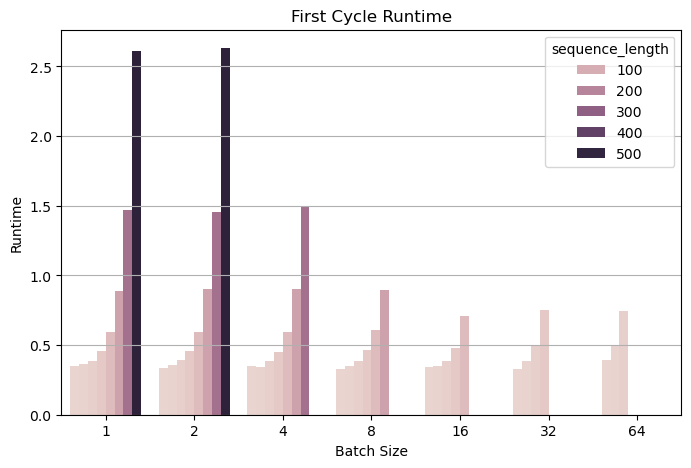

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 5))

sns.barplot(
    data=exp_first_cycle,
    x="batch_size",
    y="runtime",
    hue="sequence_length"
)

plt.title("First Cycle Runtime")
plt.xlabel("Batch Size")
plt.ylabel("Runtime")
plt.grid(True, axis="y")

plt.show()

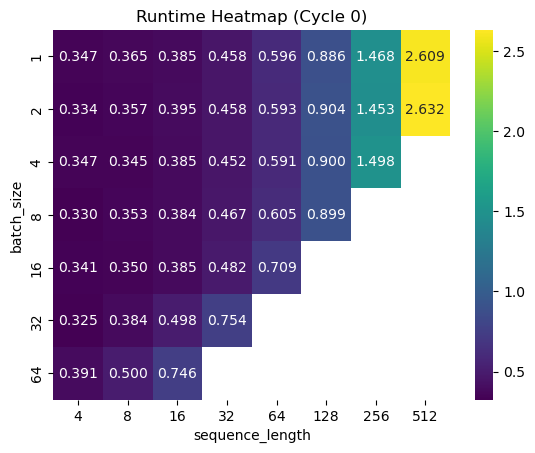

In [44]:
pivot = exp_first_cycle.pivot(
    columns="sequence_length",
    index="batch_size",
    values="runtime"
)

sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis")
plt.title("Runtime Heatmap (Cycle 0)")
plt.show()

In [40]:
exp_cache_cycles = grouped_df[grouped_df['cycle'] != 0]
exp_cache_cycles.head()

,batch_size,sequence_length,cycle,start_time,end_time,runtime
1,1,4,1,4.344430e+06,4.344430e+06,0.072311
2,1,4,2,4.344430e+06,4.344430e+06,0.064727
3,1,4,3,4.344430e+06,4.344430e+06,0.064845
4,1,4,4,4.344430e+06,4.344430e+06,0.064937
5,1,4,5,4.344430e+06,4.344430e+06,0.059244


In [41]:
avg_cache_cycles = (
    exp_cache_cycles
    .groupby(["batch_size", "sequence_length"])
    .agg(
        runtime=("runtime", "mean")
    )
    .reset_index()
)

In [42]:
avg_cache_cycles.head()

,batch_size,sequence_length,runtime
0,1,4,0.059728
1,1,8,0.060713
2,1,16,0.059520
3,1,32,0.060062
4,1,64,0.060233


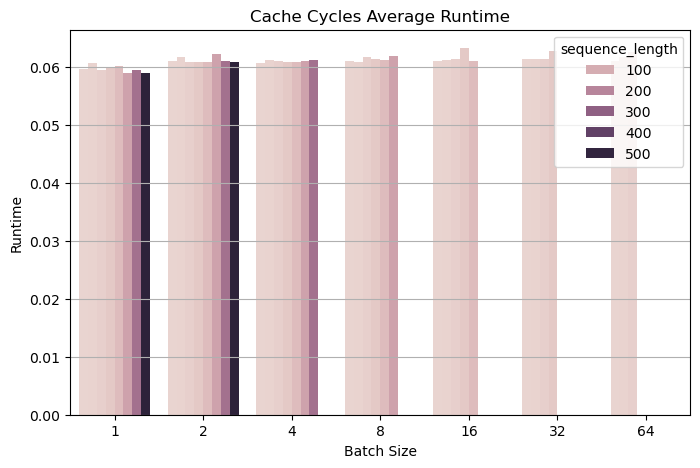

In [41]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=avg_cache_cycles,
    x="batch_size",
    y="runtime",
    hue="sequence_length"
)

plt.title("Cache Cycles Average Runtime")
plt.xlabel("Batch Size")
plt.ylabel("Runtime")
plt.grid(True, axis="y")

plt.show()

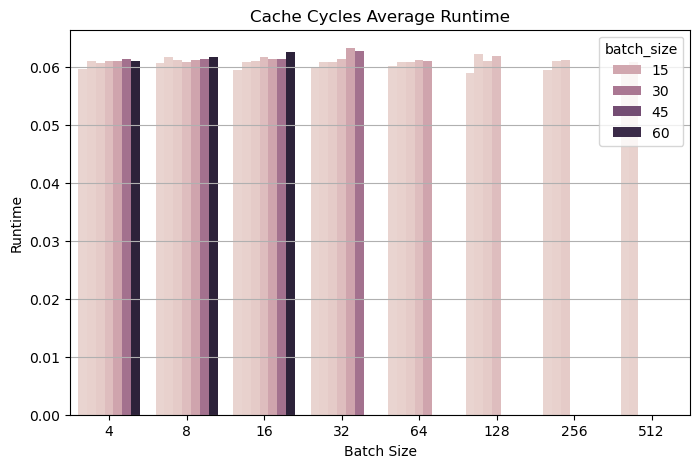

In [42]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=avg_cache_cycles,
    x="sequence_length",
    y="runtime",
    hue="batch_size"
)

plt.title("Cache Cycles Average Runtime")
plt.xlabel("Batch Size")
plt.ylabel("Runtime")
plt.grid(True, axis="y")

plt.show()

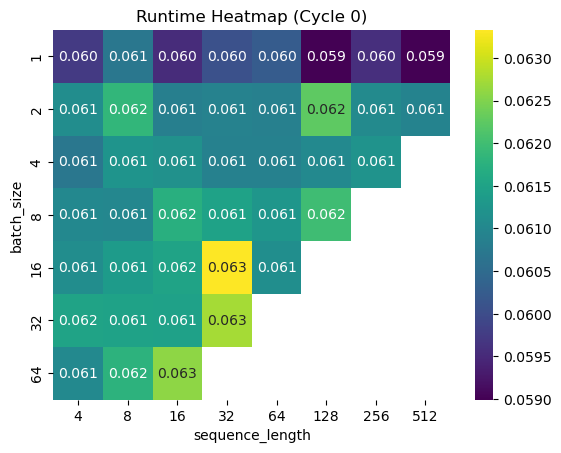

In [45]:
pivot = avg_cache_cycles.pivot(
    columns="sequence_length",
    index="batch_size",
    values="runtime"
)

sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis")
plt.title("Runtime Heatmap (Cycle 0)")
plt.show()

In [43]:
def load_latency_tp_log(file_path):
    rows = []

    seq_len = 0

    with open(file_path, "r") as f:
        for line in f:
            line = line.strip()

            # Skip empty lines
            if not line:
                continue

            parts = [p.strip() for p in line.split(",")]

            # Keep only valid rows with exactly 7 columns
            if len(parts) != 7:
                continue

            try:
                if parts[2] != "1":
                    seq_len = int(parts[2])
                rows.append([
                    parts[0],              # type
                    int(parts[1]),         # batch_size
                    seq_len,         # sequence_length
                    int(parts[3]),         # rank
                    int(parts[4]),         # cycle
                    float(parts[5]),       # start_time
                    float(parts[6])        # end_time
                ])
            except ValueError:
                # Skip garbage lines
                continue

    return pd.DataFrame(rows, columns=columns)

In [44]:
df = load_latency_tp_log(file_path="tp.log")

In [45]:
df.head()

,type,batch_size,sequence_length,rank,cycle,start_time,end_time
0,Gate,1,4,0,0,4.835212e+06,4.835212e+06
1,Gate,1,4,1,0,4.835212e+06,4.835212e+06
2,Gate,1,4,3,0,4.835212e+06,4.835212e+06
3,Gate,1,4,2,0,4.835212e+06,4.835212e+06
4,Gate,1,4,0,1,4.835212e+06,4.835212e+06


In [46]:
grouped_df = (
    df
    .groupby(["batch_size", "sequence_length", "cycle"])
    .agg(
        start_time=("start_time", "min"),
        end_time=("end_time", "max")
    )
    .reset_index()
)

In [47]:
grouped_df['runtime'] = grouped_df['end_time'] - grouped_df['start_time']

In [16]:
tp_exp_first_cycle = grouped_df[grouped_df['cycle'] == 0]
tp_exp_first_cycle.head()

,batch_size,sequence_length,cycle,start_time,end_time,runtime
0,1,4,0,4.835212e+06,4.835212e+06,0.133180
513,1,8,0,4.835271e+06,4.835271e+06,0.142778
1026,1,16,0,4.835332e+06,4.835332e+06,0.198975
1539,1,32,0,4.835392e+06,4.835392e+06,0.255122
2052,1,64,0,4.835452e+06,4.835453e+06,0.411487


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
# Merge the two experiments
merged = exp_first_cycle.merge(
    tp_exp_first_cycle,
    on=["batch_size", "sequence_length"],
    suffixes=("_ssm", "_tp")
)


In [ ]:
# Alternatively:
merged["speedup"] = merged["runtime_tp"] / merged["runtime_ssm"]

In [36]:
merged.head()

,batch_size,sequence_length,cycle_ssm,start_time_ssm,end_time_ssm,runtime_ssm,cycle_tp,start_time_tp,end_time_tp,runtime_tp,speedup
0,1,4,0,4.344430e+06,4.344430e+06,0.347168,0,4.835212e+06,4.835212e+06,0.133180,0.383620
1,1,8,0,4.344486e+06,4.344486e+06,0.364987,0,4.835271e+06,4.835271e+06,0.142778,0.391188
2,1,16,0,4.344543e+06,4.344543e+06,0.384887,0,4.835332e+06,4.835332e+06,0.198975,0.516969
3,1,32,0,4.344599e+06,4.344599e+06,0.457790,0,4.835392e+06,4.835392e+06,0.255122,0.557292
4,1,64,0,4.344655e+06,4.344656e+06,0.595563,0,4.835452e+06,4.835453e+06,0.411487,0.690921


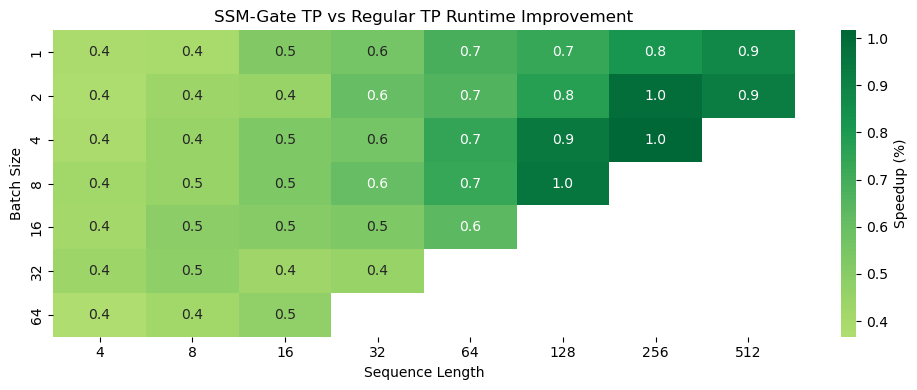

In [ ]:
# Create heatmap matrix
heatmap_data = merged.pivot(
    index="batch_size",
    columns="sequence_length",
    values="speedup"
)

# Plot
plt.figure(figsize=(10, 4))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    center=0,
    cbar_kws={"label": "Speedup (ratio)"}
)

plt.title("SSM-Gate TP vs Regular TP Runtime Improvement")
plt.xlabel("Sequence Length")
plt.ylabel("Batch Size")

plt.tight_layout()
plt.show()

In [48]:
tp_exp_cache_cycles = grouped_df[grouped_df['cycle'] != 0]
tp_exp_cache_cycles.head()

,batch_size,sequence_length,cycle,start_time,end_time,runtime
1,1,4,1,4.835212e+06,4.835212e+06,0.064114
2,1,4,2,4.835212e+06,4.835212e+06,0.059104
3,1,4,3,4.835212e+06,4.835212e+06,0.060197
4,1,4,4,4.835212e+06,4.835212e+06,0.058627
5,1,4,5,4.835212e+06,4.835213e+06,0.060583


In [49]:
tp_avg_cache_cycles = (
    tp_exp_cache_cycles
    .groupby(["batch_size", "sequence_length"])
    .agg(
        runtime=("runtime", "mean")
    )
    .reset_index()
)

In [52]:
tp_avg_cache_cycles.head()

,batch_size,sequence_length,runtime
0,1,4,0.054382
1,1,8,0.055329
2,1,16,0.055322
3,1,32,0.054881
4,1,64,0.054616


In [53]:
avg_cache_cycles.head()

,batch_size,sequence_length,runtime
0,1,4,0.059728
1,1,8,0.060713
2,1,16,0.059520
3,1,32,0.060062
4,1,64,0.060233


In [54]:
# Merge the two experiments
merged = avg_cache_cycles.merge(
    tp_avg_cache_cycles,
    on=["batch_size", "sequence_length"],
    suffixes=("_ssm", "_tp")
)

In [58]:
merged['speedup'] = merged['runtime_tp'] / merged['runtime_ssm']

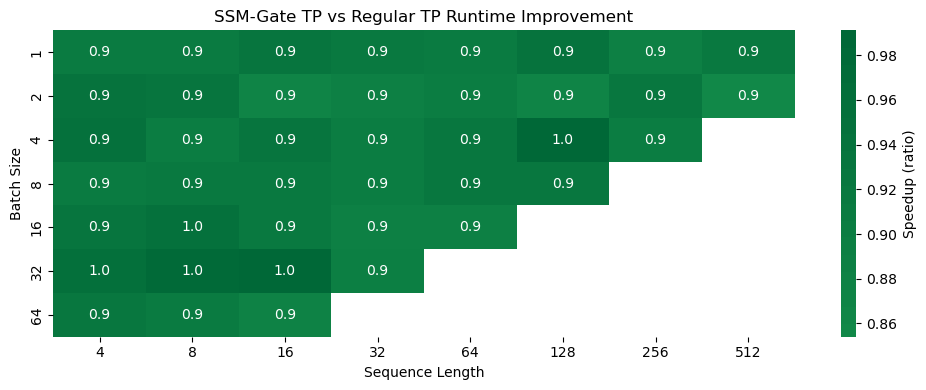

In [59]:
# Create heatmap matrix
heatmap_data = merged.pivot(
    index="batch_size",
    columns="sequence_length",
    values="speedup"
)

# Plot
plt.figure(figsize=(10, 4))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    center=0,
    cbar_kws={"label": "Speedup (ratio)"}
)

plt.title("SSM-Gate TP vs Regular TP Runtime Improvement")
plt.xlabel("Sequence Length")
plt.ylabel("Batch Size")

plt.tight_layout()
plt.show()